In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

import seaborn as sns
import requests


# LOAD DATA & EXTRACT 80 SAMPLES FOR GPT

In [20]:
print("Loading data and extracting the 80-sample test set...")
df = pd.read_csv('./resources/cn7050data.csv', encoding='latin-1', names=['sentiment', 'text'])


print("before removing duplicates:", df.shape)
print(df[df.duplicated(subset=["sentiment","text"],keep=False)])
df = df.drop_duplicates()
df=df.reset_index(drop=True)
df = df.drop_duplicates().dropna()
print("after removing duplicates:", df.shape)
df['sentiment'] = df['sentiment'].str.lower()
#df[df.duplicated(subset=["sentiment","text"],keep=False)]

#df.tail(7)


Loading data and extracting the 80-sample test set...
before removing duplicates: (4846, 2)
     sentiment                                               text
1098   neutral  The issuer is solely responsible for the conte...
1099   neutral  The issuer is solely responsible for the conte...
1415   neutral  The report profiles 614 companies including ma...
1416   neutral  The report profiles 614 companies including ma...
2395   neutral  Ahlstrom 's share is quoted on the NASDAQ OMX ...
2396   neutral  Ahlstrom 's share is quoted on the NASDAQ OMX ...
2566   neutral  SSH Communications Security Corporation is hea...
2567   neutral  SSH Communications Security Corporation is hea...
3093   neutral  Proha Plc ( Euronext :7327 ) announced today (...
3094   neutral  Proha Plc ( Euronext :7327 ) announced today (...
3205   neutral  The company serves customers in various indust...
3206   neutral  The company serves customers in various indust...
after removing duplicates: (4840, 2)


In [ ]:
OLLAMA_URL = "http://localhost:11434/api/generate" 
MODEL_NAME = "gpt-oss:20b-cloud"

In [ ]:
train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['sentiment'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['sentiment'])

gpt_test_df = test_df.sample(n=80, random_state=13).copy()
print(f"Successfully sampled {len(gpt_test_df)} headlines for GPT-OSS evaluation.\n")



def build_reasoning_prompt(headline):
    
    prompt = f"""You are an expert financial analyst. Read the following financial news headline and determine its sentiment.
    Headline: "{headline}"

Step 1: Analyze the financial implications of this headline. (Is it about growth, loss, standard operations, etc.?)
Step 2: Based on your analysis, decide if the sentiment is strictly Positive, Negative, or Neutral.

Provide your output in exactly this format:
\nReasoning: [...]
\nFinal Label: [positive / negative / neutral]
"""
    return prompt


print("Running GPT-OSS and extracting reasoning...")

def call_ollama(prompt):
    payload={
        "model":MODEL_NAME,
        "prompt":prompt,
        "stream":False,
    }
    try:
        response=requests.post(OLLAMA_URL, json=payload)
        response.raise_for_status()
        return response.json().get("response", "")
    except requests.exceptions.RequestException as e:
        print(f"Error calling Ollama API: {e}")
        return "Reasoning: Error occurred while calling Ollama API. \nFinal Label: neutral"

reasonings = []
gpt_predictions = []

for index,row in gpt_test_df.iterrows():
    headline = row['text']
    prompt = build_reasoning_prompt(headline)
    
    response_text=call_ollama(prompt)
    reasoning_match = re.search(r"Reasoning:\s*(.*?)\s*Final Label:", response_text, re.DOTALL)
    label_match = re.search(r"Final Label:\s*(\w+)", response_text, re.IGNORECASE)
    
    reasoning = reasoning_match.group(1).strip() if reasoning_match else "No reasoning found"
    label = label_match.group(1).strip().lower() if label_match else "neutral" # Important to note that the model can sometimes fail to provide a label aas positive or negative.
    reasonings.append(reasoning)
    gpt_predictions.append(label)
    
gpt_test_df['gpt_reasoning'] = reasonings
gpt_test_df['gpt_prediction'] = gpt_predictions

Successfully sampled 80 headlines for GPT-OSS evaluation.

Running GPT-OSS Inference and extracting reasoning... (This might take a few minutes)



 GPT-OSS (20B) PERFORMANCE METRICS 
Accuracy: 0.6750
Macro-F1 Score: 0.6801

--- Detailed Per-Class Report ---
              precision    recall  f1-score   support

    negative       0.55      1.00      0.71         6
     neutral       0.81      0.60      0.69        48
    positive       0.58      0.73      0.64        26

    accuracy                           0.68        80
   macro avg       0.64      0.78      0.68        80
weighted avg       0.71      0.68      0.68        80



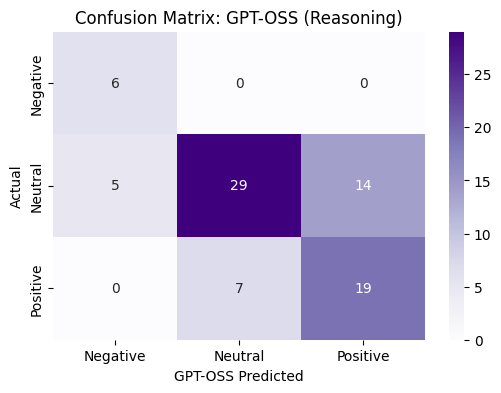

In [26]:
true_labels = gpt_test_df['sentiment'].tolist()

print("\n" + "="*40)
print(" GPT-OSS (20B) PERFORMANCE METRICS ")
print("="*40)
print(f"Accuracy: {accuracy_score(true_labels, gpt_predictions):.4f}")
print(f"Macro-F1 Score: {f1_score(true_labels, gpt_predictions, average='macro'):.4f}")

print("\n--- Detailed Per-Class Report ---")
print(classification_report(true_labels, gpt_predictions, target_names=['negative', 'neutral', 'positive']))

cm = confusion_matrix(true_labels, gpt_predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel('GPT-OSS Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: GPT-OSS (Reasoning)')
plt.show()

## Putting the Different Prompts into Action

Loading data and preparing for ablation study...
Starting Ablation Study for 1 prompts on 10 samples...
Testing P01_ZeroShot...


  0%|          | 0/10 [00:00<?, ?it/s]

Loading data and preparing for ablation study...
Starting Ablation Study for 1 prompts on 10 samples...
Testing P01_ZeroShot...


  0%|          | 0/10 [00:00<?, ?it/s]


API Error: Expecting value: line 1 column 1 (char 0)

[DEBUG] P01_ZeroShot -> Model output: NEUTRAL
[DEBUG] Reasoning: Error...


API Error: Expecting value: line 1 column 1 (char 0)

API Error: Expecting value: line 1 column 1 (char 0)

API Error: Expecting value: line 1 column 1 (char 0)

API Error: Expecting value: line 1 column 1 (char 0)

API Error: Expecting value: line 1 column 1 (char 0)

API Error: Expecting value: line 1 column 1 (char 0)

API Error: Expecting value: line 1 column 1 (char 0)

API Error: Expecting value: line 1 column 2 (char 1)

API Error: Expecting value: line 1 column 1 (char 0)

Ablation Study Results:
Prompt Strategy  Accuracy  Macro-F1
   P01_ZeroShot       0.5  0.222222


Loading data and preparing for ablation study...
Starting Ablation Study for 1 prompts on 10 samples...
Testing P01_ZeroShot...


  0%|          | 0/10 [00:00<?, ?it/s]


API Error: Expecting value: line 1 column 1 (char 0)

[DEBUG] P01_ZeroShot -> Model output: NEUTRAL
[DEBUG] Reasoning: Error...


API Error: Expecting value: line 1 column 1 (char 0)

API Error: Expecting value: line 1 column 1 (char 0)

API Error: Expecting value: line 1 column 1 (char 0)

API Error: Expecting value: line 1 column 1 (char 0)

API Error: Expecting value: line 1 column 1 (char 0)

API Error: Expecting value: line 1 column 1 (char 0)

API Error: Expecting value: line 1 column 1 (char 0)

API Error: Expecting value: line 1 column 2 (char 1)

API Error: Expecting value: line 1 column 1 (char 0)

Ablation Study Results:
Prompt Strategy  Accuracy  Macro-F1
   P01_ZeroShot       0.5  0.222222


/var/folders/vc/3kfwh15d7234657gp2jqxqj80000gn/T/ipykernel_7957/237659940.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Accuracy", y="Prompt Strategy", palette="viridis")


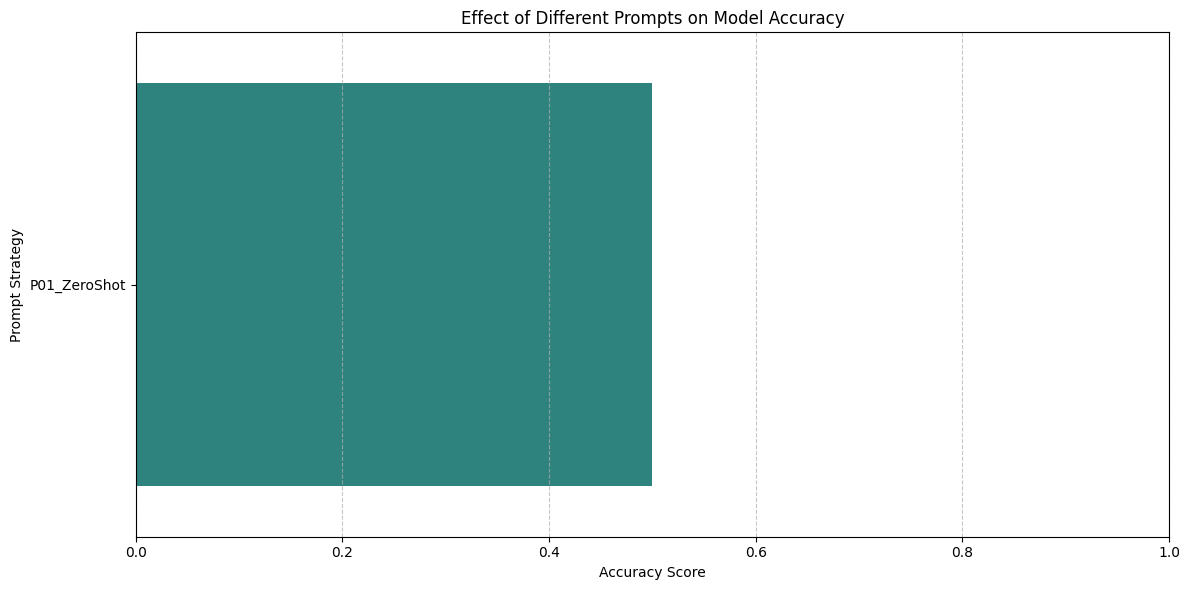

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import pandas as pd
import requests
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from pydantic import BaseModel, Field
from typing import Literal
import json 


# Model and port configuration
OLLAMA_URL = "http://localhost:11434/api/generate" 
MODEL_NAME = "gpt-oss:20b-cloud"

#Literal means the model can pick just one of the given options
class SentimentResponse(BaseModel):
    reasoning: str = Field(..., alias="Financial Reasoning")
    final_label: Literal['positive', 'negative', 'neutral'] = Field(..., alias="Final Label")

schema=SentimentResponse.model_json_schema()

print("Loading data and preparing for ablation study...")

# Reading the dataset, removing duplicates, and preparing train/val/test splits
df = pd.read_csv('./resources/cn7050data.csv', encoding='latin-1', names=['sentiment', 'text'])
df = df.drop_duplicates().reset_index(drop=True).dropna()
df['sentiment'] = df['sentiment'].str.lower()

train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['sentiment'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['sentiment'])

gpt_test_df = test_df.sample(n=80, random_state=13).copy()


# training on all the data. in the test less samples were tried by --> gpt_test_df.head(10)
#test_batch = gpt_test_df.head(10).copy()
test_batch = gpt_test_df


# prompts_dict = {
#     "P01_ZeroShot": "Analyze the sentiment of this headline: '{text}'. \nFinal Label: [positive/negative/neutral]",
#     "P10_Ultimate_Master": "Role: Financial AI. \nTask: Sentiment Classification. \nContext: '{text}'. \nProcess: 1. Extract metrics. 2. Assess market impact. 3. Output strict label. \nFinal Label: [positive/negative/neutral]"
# }

# Selection of 10 prompts for ablation study. 
prompts_dict_10 = {
    "P01_ZeroShot": "Analyze the sentiment of this headline: '{text}'. \nFinal Label: [positive/negative/neutral]",
    "P02_RolePlay": "You are a Wall Street financial analyst. Assess this headline: '{text}'. \nFinal Label: [positive/negative/neutral]",
    "P03_FewShot": "H: 'Growth is steady' -> positive. \nH: 'Layoffs announced' -> negative. \nH: 'Meeting is at 5PM' -> neutral. \nNow classify: '{text}'. \nFinal Label: [positive/negative/neutral]",
    "P04_CoT_Basic": "Read this headline: '{text}'. Let's think step by step to determine the sentiment. \nReasoning: \nFinal Label: [positive/negative/neutral]",
    "P05_CoT_ProsCons": "List reasons why '{text}' could be positive, then reasons it could be negative, then make a final decision. \nFinal Label: [positive/negative/neutral]",
    "P06_Definitions": "Rules: Positive=financial gain/growth. Negative=loss/penalty. Neutral=no financial change. Apply to: '{text}'. \nFinal Label: [positive/negative/neutral]",
    "P07_ActionOriented": "What actionable advice does '{text}' give to a shareholder? Buy(positive), Sell(negative), or Hold(neutral)? \nFinal Label: [positive/negative/neutral]",
    "P08_Keywords": "Extract the 2 most important financial words from '{text}'. Based only on those words, what is the sentiment? \nFinal Label: [positive/negative/neutral]",
    "P09_RiskAssessment": "First, rate the economic risk of '{text}' from Low to High. Then decide the sentiment. \nFinal Label: [positive/negative/neutral]",
    "P10_Ultimate_Master": "Role: Financial AI. \nTask: Sentiment Classification. \nContext: '{text}'. \nProcess: 1. Extract metrics. 2. Assess market impact. 3. Output strict label. \nFinal Label: [positive/negative/neutral]"
}

# Selection of 15 prompts for ablation study.
prompts_dict = {
    "P1_ZeroShot": "What is the sentiment of this headline: '{text}'? \nFinal Label: [positive/negative/neutral]",
    "P2_Constrained": "Classify the sentiment of this headline strictly as positive, negative, or neutral: '{text}'. \nFinal Label: [positive/negative/neutral]",
    "P3_RolePlay": "You are a Wall Street expert. Classify this headline: '{text}'. \nFinal Label: [positive/negative/neutral]",
    "P4_OneShot": "Headline: 'Profits fell 20%'. Sentiment: negative. \nHeadline: '{text}'. \nFinal Label: [positive/negative/neutral]",
    "P5_FewShot": "H: 'Growth is steady'. L: positive. \nH: 'Layoffs announced'. L: negative. \nH: 'Meeting is at 5PM'. L: neutral. \nH: '{text}'. \nFinal Label: [positive/negative/neutral]",
    "P6_CoT": "Think step-by-step about this headline: '{text}'. Explain your thoughts, then output: \nFinal Label: [positive/negative/neutral]",
    "P7_Role_CoT": "As a financial analyst, reason step-by-step about this headline: '{text}'. \nFinal Label: [positive/negative/neutral]",
    "P8_Definitions": "Positive=profit/growth, Negative=loss/layoffs, Neutral=standard ops. Classify: '{text}'. \nFinal Label: [positive/negative/neutral]",
    "P9_Action": "Would an investor buy(positive), sell(negative), or hold(neutral) based on this: '{text}'? \nFinal Label: [positive/negative/neutral]",
    "P10_Keywords": "Extract 3 key financial words from '{text}', then determine sentiment. \nFinal Label: [positive/negative/neutral]",
    "P11_Contrastive": "Argue why '{text}' might be positive, then why it might be negative. Then decide. \nFinal Label: [positive/negative/neutral]",
    "P12_Nuance": "Look for subtle financial nuances in '{text}'. Is it truly good or bad? \nFinal Label: [positive/negative/neutral]",
    "P13_Risk": "Assess the financial risk in '{text}', then assign sentiment. \nFinal Label: [positive/negative/neutral]",
    "P14_FutureFocus": "Does '{text}' imply positive future growth or negative decline? \nFinal Label: [positive/negative/neutral]",
    "P15_Ultimate": "You are a financial AI. Step 1: Analyze '{text}'. Step 2: Use definitions (pos=gain, neg=loss). Step 3: Conclude. \nFinal Label: [positive/negative/neutral]"
}

# The function to call Ollama API.
def call_ollama(prompt_text):
    json_instruction = "\n\nYou MUST respond ONLY with a raw JSON object. Do NOT use markdown code blocks (```json). Just output the raw curly braces. Keys must be 'reasoning' and 'final_label'."    
    payload = {
        "model": MODEL_NAME, 
        "prompt": prompt_text + json_instruction,
        "stream": False,
        "format": "json",
        "options": {"temperature": 0.0}
    }
    try:
        res = requests.post(OLLAMA_URL, json=payload)
        
        res.raise_for_status()
        res_text= res.json().get("response", "").strip()
        
        try:
            data=json.loads(res_text)
            label=str(data.get("final_label","neutral")).lower()
            reasoning=str(data.get("reasoning",""))
        except json.JSONDecodeError:
            print(" [Warning] JSON format failed. Using Regex fallback...")
            label_match = re.search(r"(positive|negative|neutral)", res_text, re.IGNORECASE)
            label = label_match.group(1).lower() if label_match else "NoneOfPNN"
            reasoning = "Parse error. Raw text: " + res_text[:50]
        
        if label not in ['positive', 'negative', 'neutral']:
            print(f" [Warning] Invalid label '{label}' extracted. Defaulting to 'neutral'.")
            label = "NoneOfPNN"
        return label, reasoning
    except Exception as e:
        print(f"\nAPI Error: {e}")
        return "NoneOfThem", "Error"

results_list = []
true_labels = test_batch['sentiment'].tolist()

print(f"Starting Ablation Study for {len(prompts_dict)} prompts on {len(test_batch)} samples...")

# running ollama for every prompt and collecting predictions to calculate accuracy and macro-f1 scores.
for prompt_name, prompt_template in prompts_dict.items():
    print(f"Testing {prompt_name}...")
    current_predictions = []
    
    for i, text in enumerate(tqdm(test_batch['text'], leave=False)):
        formatted_prompt = prompt_template.format(text=text)
        label,reasoning = call_ollama(formatted_prompt)
        
        if i==0:
            print(f"\n[DEBUG] {prompt_name} -> Model output: {label.upper()}")
            print(f"[DEBUG] Reasoning: {reasoning[:100]}...\n")            
        
        current_predictions.append(label)
    
    acc = accuracy_score(true_labels, current_predictions)
    f1 = f1_score(true_labels, current_predictions, average='macro')
    results_list.append({
        "Prompt Strategy": prompt_name,
        "Accuracy": acc,
        "Macro-F1": f1
    })

# Dataframe from results
results_df = pd.DataFrame(results_list).sort_values(by="Accuracy", ascending=False)
print("\nAblation Study Results:")
print(results_df.to_string(index=False))

#Plotting the results
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="Accuracy", y="Prompt Strategy", palette="viridis")
plt.title('Effect of Different Prompts on Model Accuracy')
plt.xlabel('Accuracy Score')
plt.ylabel('Prompt Strategy')
plt.xlim(0, 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

from sklearn.metrics import classification_report, confusion_matrix

print(current_predictions)

print("\n" + "="*40)
print(" GPT-OSS (20B) PERFORMANCE METRICS ")
print("="*40)
print(f"Accuracy: {accuracy_score(true_labels[:10], current_predictions):.4f}")
print(f"Macro-F1 Score: {f1_score(true_labels[:10], current_predictions, average='macro'):.4f}")

print("\n--- Detailed Per-Class Report ---")
#print(classification_report(true_labels[:10], current_predictions, target_names=['negative', 'neutral', 'positive']))

cm = confusion_matrix(true_labels[:10], current_predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel('GPT-OSS Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: GPT-OSS (Reasoning)')
plt.show()





 GPT-OSS (20B) PERFORMANCE METRICS 
Accuracy: 0.6250
Macro-F1 Score: 0.3836

--- Detailed Per-Class Report ---
              precision    recall  f1-score   support

    negative       0.50      0.17      0.25         6
     neutral       0.62      0.98      0.76        48
    positive       1.00      0.08      0.14        26

    accuracy                           0.62        80
   macro avg       0.71      0.41      0.38        80
weighted avg       0.73      0.62      0.52        80



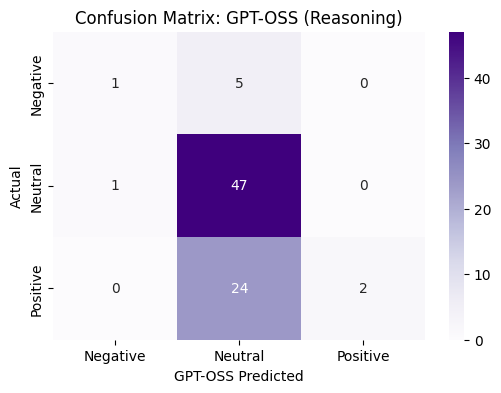

['neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'positive', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'negative', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'positive', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'negative', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral']


In [7]:
from sklearn.metrics import classification_report, confusion_matrix

true_labels = gpt_test_df['sentiment'].tolist()
print(current_predictions)

print("\n" + "="*40)
print(" GPT-OSS (20B) PERFORMANCE METRICS ")
print("="*40)
print(f"Accuracy: {accuracy_score(true_labels[:10], current_predictions):.4f}")
print(f"Macro-F1 Score: {f1_score(true_labels[:10], current_predictions, average='macro'):.4f}")

print("\n--- Detailed Per-Class Report ---")
#print(classification_report(true_labels[:10], current_predictions, target_names=['negative', 'neutral', 'positive']))

cm = confusion_matrix(true_labels[:10], current_predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel('GPT-OSS Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: GPT-OSS (Reasoning)')
plt.show()


# Last Narative

In [ ]:
import pandas as pd
import os
import requests
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

OLLAMA_URL = "http://localhost:11434/api/generate" 
MODEL_NAME = "gpt-oss:20b-cloud"

from openai import OpenAI
client = OpenAI(
    base_url="https://api.groq.com/openai/v1",
    api_key=os.environ["GROQ_API_KEY"]
)
MODEL_ID = "openai/gpt-oss-20b"

print("Loading data and preparing for ablation study...")

df = pd.read_csv('./resources/cn7050data.csv', encoding='latin-1', names=['sentiment', 'text'])
df = df.drop_duplicates().reset_index(drop=True).dropna()
df['sentiment'] = df['sentiment'].str.lower()

train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['sentiment'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['sentiment'])

gpt_test_df = test_df.sample(n=80, random_state=13).copy()
test_batch = gpt_test_df


In [ ]:
master_prompts_dict = {
    # ==========================================
    #  Zero-Shot  
    # ==========================================
    "P01_Basic": "Analyze the sentiment of this headline: '{text}'. \nFinal Label: [positive/negative/neutral]",
    "P02_Strict": "Classify this text as exactly one of these words (positive, negative, neutral) and nothing else: '{text}'. \nFinal Label: [positive/negative/neutral]",
    "P03_Question": "Is the following news positive, negative, or neutral? '{text}' \nFinal Label: [positive/negative/neutral]",
    "P04_Instructional": "Your task is sentiment analysis. Read '{text}' and output the class. \nFinal Label: [positive/negative/neutral]",
    
    # ==========================================
    #  د(Role-Playing)
    # ==========================================
    "P05_Analyst": "You are a senior Wall Street financial analyst. Assess this headline: '{text}'. \nFinal Label: [positive/negative/neutral]",
    "P06_DayTrader": "You are an aggressive day trader looking for market signals. How do you view this news: '{text}'? \nFinal Label: [positive/negative/neutral]",
    "P07_ConservativeBanker": "You are a risk-averse, conservative banker. Evaluate this statement: '{text}'. \nFinal Label: [positive/negative/neutral]",
    "P08_RetailInvestor": "You are a regular retail investor. Does this news make you feel good or bad about the stock? '{text}' \nFinal Label: [positive/negative/neutral]",
    
    # ==========================================
    #  (In-Context / Few-Shot Learning)
    # ==========================================
    "P09_OneShot": "Example - Headline: 'Profits fell 20%'. Final Label: negative. \nNow do this one: '{text}'. \nFinal Label: [positive/negative/neutral]",
    "P10_TwoShot_Extremes": "H: 'Revenue doubled' -> positive. \nH: 'Bankruptcy filed' -> negative. \nNow: '{text}'. \nFinal Label: [positive/negative/neutral]",
    "P11_ThreeShot_Balanced": "H: 'Growth is steady' -> positive. \nH: 'Layoffs announced' -> negative. \nH: 'Meeting is at 5PM' -> neutral. \nNow classify: '{text}'. \nFinal Label: [positive/negative/neutral]",
    "P12_HardExamples": "H: 'Losses were smaller than expected' -> positive. \nH: 'CEO steps down amid scandal' -> negative. \nNow classify: '{text}'. \nFinal Label: [positive/negative/neutral]",
    
    # ==========================================
    # (Chain-of-Thought & Reasoning)
    # ==========================================
    "P13_ZeroShot_CoT": "Read this headline: '{text}'. Let's think step by step to determine the sentiment. \nReasoning: \nFinal Label: [positive/negative/neutral]",
    "P14_Structured_CoT": "Headline: '{text}'. \nStep 1: Identify key financial entities. \nStep 2: Identify financial impact (up/down). \nStep 3: Conclude sentiment. \nFinal Label: [positive/negative/neutral]",
    "P15_ProsCons_CoT": "List reasons why '{text}' could be positive, then reasons it could be negative, then make a final decision. \nFinal Label: [positive/negative/neutral]",
    "P16_Contrastive": "Compare the potential good and bad outcomes of this news: '{text}'. Which outweighs the other? \nFinal Label: [positive/negative/neutral]",
    "P17_SelfCorrection": "Analyze '{text}'. Check if you are biased. Adjust if necessary, then output the label. \nFinal Label: [positive/negative/neutral]",
    
    # ==========================================
    # (Constraints & Rule-Based)
    # ==========================================
    "P18_DictionaryDefs": "Rules: Positive=financial gain/growth. Negative=loss/penalty. Neutral=no financial change. Apply to: '{text}'. \nFinal Label: [positive/negative/neutral]",
    "P19_NoNeutralAllowed": "Force a decision. Even if it seems neutral, lean towards positive or negative for: '{text}'. \nFinal Label: [positive/negative/neutral]",
    "P20_LengthConstraint": "Explain the sentiment of '{text}' in exactly one short sentence, then label it. \nFinal Label: [positive/negative/neutral]",
    "P21_KeywordExtraction": "Extract the 2 most important financial words from '{text}'. Based only on those words, what is the sentiment? \nFinal Label: [positive/negative/neutral]",
    
    # ==========================================
    # (Nuance & Metacognitive)
    # ==========================================
    "P22_SarcasmCheck": "Financial news can be dry or misleading. Look past the surface of '{text}' to find the true economic sentiment. \nFinal Label: [positive/negative/neutral]",
    "P23_RiskAssessment": "First, rate the economic risk of '{text}' from Low to High. Then decide the sentiment. \nFinal Label: [positive/negative/neutral]",
    "P24_FutureImpact": "Ignore the past. Focus only on how '{text}' affects the company's future revenue. \nFinal Label: [positive/negative/neutral]",
    "P25_MultiPerspective": "How would a buyer see '{text}'? How would a seller see it? What is the consensus? \nFinal Label: [positive/negative/neutral]",
    "P26_ConfidenceScore": "Analyze '{text}'. State your confidence level (0-100%). If confidence is low, output neutral. \nFinal Label: [positive/negative/neutral]",
    "P27_MarketMovement": "Would '{text}' cause the stock price to go UP (positive), DOWN (negative), or FLAT (neutral)? \nFinal Label: [positive/negative/neutral]",
    "P28_ToneAnalysis": "What is the emotional tone of the journalist who wrote '{text}'? \nFinal Label: [positive/negative/neutral]",
    "P29_ActionOriented": "What actionable advice does '{text}' give to a shareholder? Buy, Sell, or Hold? \nFinal Label: [positive/negative/neutral]",
    "P30_TheUltimate_Master": "Role: Financial AI. \nTask: Sentiment Classification. \nContext: '{text}'. \nProcess: 1. Extract metrics. 2. Assess market impact. 3. Output strict label. \nFinal Label: [positive/negative/neutral]"
}

In [ ]:
import pandas as pd
import os
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from openai import OpenAI

client = OpenAI(
    base_url="https://api.groq.com/openai/v1",
    api_key=os.environ["GROQ_API_KEY"]
)

MODEL_ID = "ogpt-oss-20b-cloud"

print("Loading data and preparing for ablation study...")

df = pd.read_csv('./resources/cn7050data.csv', encoding='latin-1', names=['sentiment', 'text'])
df = df.drop_duplicates().reset_index(drop=True).dropna()
df['sentiment'] = df['sentiment'].str.lower()

train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['sentiment'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['sentiment'])

gpt_test_df = test_df.sample(n=80, random_state=13).copy()

# Currently testing on 5 samples. Change to 'gpt_test_df.copy()' to run all 80 later.
test_batch = gpt_test_df

prompts_dict = {
    "P1_ZeroShot": "What is the sentiment of this headline: '{text}'? \nFinal Label: [positive/negative/neutral]",
    "P2_Constrained": "Classify the sentiment of this headline strictly as positive, negative, or neutral: '{text}'. \nFinal Label: [positive/negative/neutral]",
    "P3_RolePlay": "You are a Wall Street expert. Classify this headline: '{text}'. \nFinal Label: [positive/negative/neutral]",
    "P4_OneShot": "Headline: 'Profits fell 20%'. Sentiment: negative. \nHeadline: '{text}'. \nFinal Label: [positive/negative/neutral]",
    "P5_FewShot": "H: 'Growth is steady'. L: positive. \nH: 'Layoffs announced'. L: negative. \nH: 'Meeting is at 5PM'. L: neutral. \nH: '{text}'. \nFinal Label: [positive/negative/neutral]",
    "P6_CoT": "Think step-by-step about this headline: '{text}'. Explain your thoughts, then output: \nFinal Label: [positive/negative/neutral]",
    "P7_Role_CoT": "As a financial analyst, reason step-by-step about this headline: '{text}'. \nFinal Label: [positive/negative/neutral]",
    "P8_Definitions": "Positive=profit/growth, Negative=loss/layoffs, Neutral=standard ops. Classify: '{text}'. \nFinal Label: [positive/negative/neutral]",
    "P9_Action": "Would an investor buy(positive), sell(negative), or hold(neutral) based on this: '{text}'? \nFinal Label: [positive/negative/neutral]",
    "P10_Keywords": "Extract 3 key financial words from '{text}', then determine sentiment. \nFinal Label: [positive/negative/neutral]",
    "P11_Contrastive": "Argue why '{text}' might be positive, then why it might be negative. Then decide. \nFinal Label: [positive/negative/neutral]",
    "P12_Nuance": "Look for subtle financial nuances in '{text}'. Is it truly good or bad? \nFinal Label: [positive/negative/neutral]",
    "P13_Risk": "Assess the financial risk in '{text}', then assign sentiment. \nFinal Label: [positive/negative/neutral]",
    "P14_FutureFocus": "Does '{text}' imply positive future growth or negative decline? \nFinal Label: [positive/negative/neutral]",
    "P15_Ultimate": "You are a financial AI. Step 1: Analyze '{text}'. Step 2: Use definitions (pos=gain, neg=loss). Step 3: Conclude. \nFinal Label: [positive/negative/neutral]"
}

def call_groq(prompt_text):
    try:
        response = client.chat.completions.create(
            model=MODEL_ID,
            messages=[
                {"role": "user", "content": prompt_text}
            ],
            temperature=0.1 # Low temperature for more consistent classification
        )
        return response.choices[0].message.content
    except Exception as e:
        print(f"\nAPI Error: {e}")
        return ""


results_list = []
true_labels = test_batch['sentiment'].tolist()

print(f"Starting Ablation Study for {len(prompts_dict)} prompts on {len(test_batch)} samples...")

for prompt_name, prompt_template in prompts_dict.items():
    print(f"Testing {prompt_name}...")
    current_predictions = []
    
    for text in tqdm(test_batch['text'], leave=False):
        formatted_prompt = prompt_template.format(text=text)
        #response = call_groq(formatted_prompt)
        response=call_ollama(formatted_prompt)
        
        label_match = re.search(r"Final Label:\s*(\w+)", response, re.IGNORECASE)
        pred = label_match.group(1).lower() if label_match else "neutral"
        current_predictions.append(pred)
    
    acc = accuracy_score(true_labels, current_predictions)
    f1 = f1_score(true_labels, current_predictions, average='macro')
    
    results_list.append({
        "Prompt Strategy": prompt_name,
        "Accuracy": acc,
        "Macro-F1": f1
    })



results_df = pd.DataFrame(results_list).sort_values(by="Accuracy", ascending=False)
print("\nAblation Study Results:")
print(results_df.to_string(index=False))

plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="Accuracy", y="Prompt Strategy", palette="viridis")
plt.title('Effect of Different Prompts on Model Accuracy')
plt.xlabel('Accuracy Score')
plt.ylabel('Prompt Strategy')
plt.xlim(0, 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Loading data and preparing for ablation study...
Starting Ablation Study for 15 prompts on 80 samples...
Testing P1_ZeroShot...


  0%|          | 0/80 [00:00<?, ?it/s]

Loading data and preparing for ablation study...
Starting Ablation Study for 15 prompts on 80 samples...
Testing P1_ZeroShot...


  0%|          | 0/80 [00:00<?, ?it/s]

Testing P2_Constrained...


...

  0%|          | 0/80 [00:00<?, ?it/s]


API Error: Error code: 429 - {'error': {'message': 'Rate limit reached for model `openai/gpt-oss-20b` in organization `org_01j435p9hdfr7rmvhf85zf43xv` service tier `on_demand` on tokens per day (TPD): Limit 200000, Used 200000, Requested 149. Please try again in 1m4.367999999s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

API Error: Error code: 429 - {'error': {'message': 'Rate limit reached for model `openai/gpt-oss-20b` in organization `org_01j435p9hdfr7rmvhf85zf43xv` service tier `on_demand` on tokens per day (TPD): Limit 200000, Used 200000, Requested 141. Please try again in 1m0.912s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

API Error: Error code: 429 - {'error': {'message': 'Rate limit reached for model `openai/gpt-oss-20b` in organization `org_01j435p9hdfr7rmvhf85zf43xv` service tier

  0%|          | 0/80 [00:00<?, ?it/s]


API Error: Error code: 429 - {'error': {'message': 'Rate limit reached for model `openai/gpt-oss-20b` in organization `org_01j435p9hdfr7rmvhf85zf43xv` service tier `on_demand` on tokens per day (TPD): Limit 200000, Used 200000, Requested 146. Please try again in 1m3.071999999s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

API Error: Error code: 429 - {'error': {'message': 'Rate limit reached for model `openai/gpt-oss-20b` in organization `org_01j435p9hdfr7rmvhf85zf43xv` service tier `on_demand` on tokens per day (TPD): Limit 200000, Used 200000, Requested 153. Please try again in 1m6.095999999s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

API Error: Error code: 429 - {'error': {'message': 'Rate limit reached for model `openai/gpt-oss-20b` in organization `org_01j435p9hdfr7rmvhf85zf43xv` servic

KeyboardInterrupt: 